<a href="https://colab.research.google.com/github/remyaP12/AI-Based-Flood-Prediction-and-Early-Warning-System/blob/main/scania_projectConfusion%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
from google.colab import drive
drive.mount('/content/drive')

# Folder in your Google Drive containing the 9 Scania CSVs:
# train_operational_readouts.csv, train_specifications.csv, train_tte.csv,
# validation_operational_readouts.csv, validation_specifications.csv, validation_labels.csv,
# test_operational_readouts.csv, test_specifications.csv, test_labels.csv
DRIVE_DATA_ROOT = "/content/drive/MyDrive/scania"  # <-- edit this path if your folder is named differently


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
import os
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, recall_score, balanced_accuracy_score, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

warnings.filterwarnings('ignore')

In [44]:
USE_CORRELATION_FILTER = True
CORRELATION_THRESHOLD = 0.98
USE_DOWNSAMPLING_FOR_SEVERITY = True
USE_CALIBRATION = True

MIN_RECALL = 0.70
RECALL_CONSTRAINT_BINARY = 0.75   # Proven working
BINARY_FP_COST = 10
BINARY_FN_COST = 500

DATA_ROOT = DRIVE_DATA_ROOT

COST_MATRIX = np.array([
    [0,   7,   8,   9,  10],
    [200, 0,   7,   8,   9],
    [300, 200, 0,   7,   8],
    [400, 300, 200, 0,   7],
    [500, 400, 300, 200, 0]
], dtype=np.float32)

PAPER_COST = 36314
PAPER_VALIDATION_COST = 36113

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)


In [45]:
def plot_confusion_matrix(cm, classes, title, filename):
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    plt.close()

def plot_cost_weighted_confusion(y_true, y_pred, cost_matrix, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4])
    cost_cm = cm * cost_matrix
    plt.figure(figsize=(10,8))
    sns.heatmap(cost_cm, annot=True, fmt='.0f', cmap='OrRd', xticklabels=range(5), yticklabels=range(5))
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    plt.close()

def plot_class_recall(y_true, y_pred, title, filename):
    recalls = []
    for i in range(5):
        if (y_true == i).sum() > 0:
            rec = recall_score(y_true, y_pred, labels=[i], average=None)[0]
        else:
            rec = 0.0
        recalls.append(rec)
    plt.figure(figsize=(10,6))
    bars = plt.bar(range(5), recalls, color='teal')
    plt.ylim(0,1)
    plt.xlabel('Class')
    plt.ylabel('Recall')
    plt.title(title)
    plt.xticks(range(5), ['0','1','2','3','4'])
    for bar, r in zip(bars, recalls):
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{r:.3f}', ha='center')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    plt.close()

def plot_roc_curve(probs, y_true, title, filename):
    binary = (y_true > 0).astype(int)
    fpr, tpr, _ = roc_curve(binary, probs)
    auc_val = auc(fpr, tpr)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'AUC = {auc_val:.3f}', linewidth=2)
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    plt.close()
    return auc_val

def plot_pr_curve(probs, y_true, title, filename):
    binary = (y_true > 0).astype(int)
    precision, recall, _ = precision_recall_curve(binary, probs)
    plt.figure(figsize=(8,6))
    plt.plot(recall, precision, linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    plt.close()

def print_confusion_matrix_paper_format(cm, title, class_labels=[0,1,2,3,4]):
    print(f"\n{title}")
    print("-" * 60)
    print(f"{'Actual':>6} |", end="")
    for c in class_labels:
        print(f" {c:>6}", end="")
    print("\n" + "-" * 60)
    for i, row in enumerate(cm):
        print(f"{class_labels[i]:>6} |", end="")
        for val in row:
            print(f" {val:6d}", end="")
        print()
    print("-" * 60)

In [63]:
def load_raw_data():
    print("\n LOADING DATA")
    train_op = pd.read_csv(os.path.join(DATA_ROOT, 'train_operational_readouts.csv'))
    train_spec = pd.read_csv(os.path.join(DATA_ROOT, 'train_specifications.csv'))
    train_tte = pd.read_csv(os.path.join(DATA_ROOT, 'train_tte.csv'))
    val_op = pd.read_csv(os.path.join(DATA_ROOT, 'validation_operational_readouts.csv'))
    val_spec = pd.read_csv(os.path.join(DATA_ROOT, 'validation_specifications.csv'))
    val_labels = pd.read_csv(os.path.join(DATA_ROOT, 'validation_labels.csv'))
    test_op = pd.read_csv(os.path.join(DATA_ROOT, 'test_operational_readouts.csv'))
    test_spec = pd.read_csv(os.path.join(DATA_ROOT, 'test_specifications.csv'))
    test_labels = pd.read_csv(os.path.join(DATA_ROOT, 'test_labels.csv'))
    return (train_op, train_spec, train_tte,
            val_op, val_spec, val_labels,
            test_op, test_spec, test_labels)

def create_labels(train_op, train_tte, val_labels, test_labels):
    print("\n CREATING LABELS")
    last_obs = train_op.groupby('vehicle_id')['time_step'].max().reset_index()
    last_obs.columns = ['vehicle_id', 'last_time_step']
    train = train_tte.merge(last_obs, on='vehicle_id', how='left')

    def get_class(row):
        if row['in_study_repair'] == 0:
            return 0
        delta = row['length_of_study_time_step'] - row['last_time_step']
        if delta < 2: return 4
        elif delta < 4: return 3
        elif delta < 6: return 2
        else: return 1

    train['class'] = train.apply(get_class, axis=1)
    val = val_labels.copy()
    if 'class_label' in val.columns:
        val.rename(columns={'class_label': 'class'}, inplace=True)
    test = test_labels.copy()
    if 'class_label' in test.columns:
        test.rename(columns={'class_label': 'class'}, inplace=True)
    print(f"Train class counts: {dict(zip(*np.unique(train['class'], return_counts=True)))}")
    return train, val, test

def encode_specs(train_spec, val_spec, test_spec):
    print("\n ENCODING SPECIFICATIONS")
    spec_cols = [f'Spec_{i}' for i in range(8)]
    encoded_cols = []
    for col in spec_cols:
        freq = train_spec[col].value_counts().to_dict()
        train_spec[col + '_freq'] = train_spec[col].map(freq).fillna(0)
        val_spec[col + '_freq'] = val_spec[col].map(freq).fillna(0)
        test_spec[col + '_freq'] = test_spec[col].map(freq).fillna(0)
        encoded_cols.append(col + '_freq')

        categories = sorted(train_spec[col].unique())
        cat_to_int = {cat: i+1 for i, cat in enumerate(categories)}
        train_spec[col + '_label'] = train_spec[col].map(cat_to_int).fillna(0).astype(int)
        val_spec[col + '_label'] = val_spec[col].map(lambda x: cat_to_int.get(x, 0)).astype(int)
        test_spec[col + '_label'] = test_spec[col].map(lambda x: cat_to_int.get(x, 0)).astype(int)
        encoded_cols.append(col + '_label')

    train_enc = train_spec[['vehicle_id'] + encoded_cols]
    val_enc = val_spec[['vehicle_id'] + encoded_cols]
    test_enc = test_spec[['vehicle_id'] + encoded_cols]
    print(f"Created {len(encoded_cols)} spec features")
    return train_enc, val_enc, test_enc, len(encoded_cols)

def create_sequences_no_padding(op_df, spec_enc, labels_df, max_len=50):
    print(f"\nCreating sequences WITHOUT padding...")
    vehicle_ids = op_df['vehicle_id'].unique()
    sensor_cols = [c for c in op_df.columns if c not in ['vehicle_id', 'time_step']]
    n_sensors = len(sensor_cols)
    spec_dict = spec_enc.set_index('vehicle_id').to_dict('index')
    label_dict = labels_df.set_index('vehicle_id')['class'].to_dict()
    sequences, specs, targets = [], [], []

    for vid in vehicle_ids:
        veh_op = op_df[op_df['vehicle_id'] == vid].sort_values('time_step')
        if len(veh_op) == 0: continue
        seq = veh_op[sensor_cols].values.astype(np.float32)
        df_seq = pd.DataFrame(seq).ffill().bfill()
        seq = df_seq.values
        seq = np.nan_to_num(seq, nan=0.0)
        if len(seq) > max_len:
            seq = seq[-max_len:]
        sequences.append(seq)
        spec_row = spec_dict.get(vid)
        if spec_row is None:
            spec_vals = np.zeros(len(spec_enc.columns)-1, dtype=np.float32)
        else:
            spec_vals = np.array([spec_row.get(col, 0) for col in spec_enc.columns if col != 'vehicle_id'], dtype=np.float32)
        specs.append(spec_vals)
        targets.append(label_dict.get(vid, 0))

    print(f"   Created {len(sequences)} sequences")
    return sequences, np.array(specs, dtype=np.float32), np.array(targets, dtype=np.int32)

def extract_features_variable(sequences, specs, k=20):
    n_samples = len(sequences)
    n_sensors = sequences[0].shape[1]
    all_features = []

    for i in range(n_samples):
        seq = sequences[i]
        spec = specs[i]
        seq_len = seq.shape[0]
        window = seq[-min(seq_len, k):, :]
        actual_k = window.shape[0]
        if actual_k == 0:
            window = np.zeros((1, n_sensors))
            actual_k = 1

        mean = np.mean(window, axis=0)
        std = np.std(window, axis=0)
        min_val = np.min(window, axis=0)
        max_val = np.max(window, axis=0)
        median = np.median(window, axis=0)
        q25 = np.percentile(window, 25, axis=0)
        q75 = np.percentile(window, 75, axis=0)

        if actual_k > 1:
            x = np.arange(actual_k)
            slopes = np.polyfit(x, window, 1)[0]
            delta = window[-1, :] - window[0, :]
            ratio = window[-1, :] / (window[0, :] + 1e-6)
            volatility = np.std(np.diff(window, axis=0), axis=0)
        else:
            slopes = np.zeros(n_sensors)
            delta = np.zeros(n_sensors)
            ratio = np.ones(n_sensors)
            volatility = np.zeros(n_sensors)

        ratio = np.clip(ratio, -10, 10)
        sample_features = np.concatenate([
            mean, std, min_val, max_val, median, q25, q75,
            slopes, delta, ratio, volatility, spec
        ])
        all_features.append(sample_features)

    result = np.array(all_features, dtype=np.float32)
    result = np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)
    return result

def correlation_filter(X_train, X_val, X_test, threshold=0.98):
    print(f"\n Correlation filter...")
    sample_size = min(5000, X_train.shape[0])
    indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
    corr_matrix = pd.DataFrame(X_train[indices]).corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    if len(to_drop) > 0 and len(to_drop) < X_train.shape[1]:
        X_train = np.delete(X_train, to_drop, axis=1)
        X_val = np.delete(X_val, to_drop, axis=1)
        X_test = np.delete(X_test, to_drop, axis=1)
        print(f"   Kept {X_train.shape[1]} features")
    return X_train, X_val, X_test
def downsample_training(X, y):
    print("\n Downsampling (severity model: classes 1-4 only)...")
    df = pd.DataFrame(X)
    df['target'] = y
    df = df[df['target'] != 0]          # drop class 0 completely
    print(f"   Kept {len(df)} fault samples (classes 1-4)")
    X_bal = df.drop('target', axis=1).values
    y_bal = df['target'].values
    return X_bal, y_bal
# def downsample_training(X, y):
#     print("\n Downsampling...")
#     df = pd.DataFrame(X)
#     df['target'] = y
#     majority = df[df['target'] == 0]
#     minority = df[df['target'] != 0]
#     if len(majority) > len(minority):
#         majority_down = majority.sample(n=len(minority), random_state=42)
#         df_balanced = pd.concat([majority_down, minority]).sample(frac=1, random_state=42)
#         X_bal = df_balanced.drop('target', axis=1).values
#         y_bal = df_balanced['target'].values
#         print(f"   Downsampled to {len(df_balanced)} samples")
#         return X_bal, y_bal
#     return X, y

def get_severity_weights(y, alpha=0.85):
    freq = np.bincount(y)
    sev = {0: 200, 1: 300, 2: 400, 3: 500, 4: 500}
    weights = np.zeros(len(y))
    for i, cls in enumerate(y):
        if freq[cls] > 0:
            weights[i] = alpha * (1.0 / freq[cls]) * (sev[cls] / sev[0])
        else:
            weights[i] = 1.0
    weights = weights / weights.mean()
    return weights

def cost_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    return -sum(COST_MATRIX[int(t), int(p)] for t, p in zip(y, y_pred))

In [64]:
def train_binary_fault_detector(X_train, y_train, X_val, y_val):
    print("\n Training Binary Fault Detector...")

    y_bin = (y_train > 0).astype(int)
    y_val_bin = (y_val > 0).astype(int)

    pos = y_bin.sum()
    neg = len(y_bin) - pos
    scale_pos_weight = (BINARY_FN_COST / BINARY_FP_COST) * (neg / max(pos, 1))
    scale_pos_weight = min(scale_pos_weight, 20)   # cap to prevent probability collapse

    print(f"   Binary: normal={neg}, fault={pos}, scale_pos_weight={scale_pos_weight:.2f}")
    print(f"   Recall constraint: {RECALL_CONSTRAINT_BINARY}")

    lgb_params = {
        'objective': 'binary', 'metric': 'binary_logloss',
        'scale_pos_weight': scale_pos_weight,
        'learning_rate': 0.03, 'num_leaves': 31, 'max_depth': -1,
        'min_data_in_leaf': 500, 'lambda_l1': 1.0,
        'verbosity': -1, 'random_state': 81
    }
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(X_train, y_bin)

    val_probs = model.predict_proba(X_val)[:, 1]
    thresholds = np.concatenate([np.linspace(0.001, 0.02, 50),
                                 np.linspace(0.02, 0.10, 40),
                                 np.linspace(0.10, 0.30, 30)])
    best_th = 0.01
    best_cost = float('inf')
    best_recall = 0
    fallback_th = 0.01
    fallback_cost = float('inf')

    for th in thresholds:
        pred = (val_probs >= th).astype(int)
        recall = recall_score(y_val_bin, pred)
        tn, fp, fn, tp = confusion_matrix(y_val_bin, pred, labels=[0,1]).ravel()
        cost = fp * BINARY_FP_COST + fn * BINARY_FN_COST
        if cost < fallback_cost:
            fallback_cost = cost
            fallback_th = th
        if recall >= RECALL_CONSTRAINT_BINARY:
            if cost < best_cost:
                best_cost = cost
                best_th = th
                best_recall = recall
                print(f"      th={th:.4f}, recall={recall:.3f}, cost={cost:.0f}")

    if best_recall == 0:
        print(f"    No threshold satisfied recall ≥ {RECALL_CONSTRAINT_BINARY}")
        print(f"   Using fallback threshold: {fallback_th:.4f}")
        best_th = fallback_th
        best_recall = recall_score(y_val_bin, (val_probs >= best_th).astype(int))

    print(f"   Selected: threshold={best_th:.4f}, recall={best_recall:.3f}")
    return model, best_th


In [65]:
def train_voting_ensemble(X_train, y_train, X_val, y_val, seed):
    print("\n Training Voting Ensemble (SVM + RF + LightGBM)...")
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    sample_weights = get_severity_weights(y_train)

    # LightGBM
    print("   → LightGBM...")
    lgbm = lgb.LGBMClassifier(random_state=seed, verbosity=-1, objective='multiclass', num_class=5)
    lgbm.set_params(n_estimators=500, max_depth=10, learning_rate=0.05)
    lgbm.fit(X_train, y_train, sample_weight=sample_weights)
    lgbm_pred = lgbm.predict(X_val)
    lgbm_cost = sum(COST_MATRIX[int(y_val[i]), int(lgbm_pred[i])] for i in range(len(y_val)))
    print(f"      LightGBM validation cost: {lgbm_cost:.0f}")

    # SVM
    print("   → SVM...")
    svm = SVC(probability=True, random_state=seed, class_weight='balanced')
    svm.fit(X_train, y_train)

    # Random Forest
    print("   → Random Forest...")
    rf = RandomForestClassifier(random_state=seed, class_weight='balanced', n_estimators=200, n_jobs=-1)
    rf.fit(X_train, y_train)

    # Voting ensemble
    print("   → Creating Voting Ensemble...")
    voting = VotingClassifier(estimators=[('svm', svm), ('rf', rf), ('lgbm', lgbm)],
                              voting='soft', weights=[1, 1, 2])
    voting.fit(X_train, y_train)
    calibrated = CalibratedClassifierCV(voting, method='sigmoid', cv=3)
    calibrated.fit(X_train, y_train)

    val_pred = calibrated.predict(X_val)
    val_cost = sum(COST_MATRIX[int(y_val[i]), int(val_pred[i])] for i in range(len(y_val)))
    print(f"      Ensemble validation cost: {val_cost:.0f}")
    return calibrated


In [66]:
def predict_with_override(binary_pred, severity_probs, severity_pred, c4_th):
    final = np.zeros_like(binary_pred, dtype=int)
    fault_mask = binary_pred == 1
    final[~fault_mask] = 0
    for i in np.where(fault_mask)[0]:
        if severity_probs[i] > c4_th:
            final[i] = 4
        elif severity_pred[i] == 4:
            final[i] = 3
        else:
            final[i] = severity_pred[i] if severity_pred[i] != 0 else 1  # floor at least-severe fault
    return final

In [ ]:
# def main():
#     print("\n" + "="*80)
#     print(" SCANIA SCIENTIFICALLY VALID PIPELINE (NO TEST LEAKAGE)")
#     print("   Thresholds tuned on VALIDATION only → final test evaluation ONCE")
#     print("="*80)

#     # Create directories
#     os.makedirs('plots', exist_ok=True)
#     os.makedirs('saved_models', exist_ok=True)

#     # Load and preprocess data
#     (train_op, train_spec, train_tte,
#      val_op, val_spec, val_labels,
#      test_op, test_spec, test_labels) = load_raw_data()

#     train_labels, val_labels, test_labels = create_labels(train_op, train_tte, val_labels, test_labels)
#     train_spec_enc, val_spec_enc, test_spec_enc, n_specs = encode_specs(train_spec, val_spec, test_spec)

#     max_len = 50
#     print("\n CREATING SEQUENCES (NO PADDING)...")
#     train_seq, train_spec_arr, train_y = create_sequences_no_padding(train_op, train_spec_enc, train_labels, max_len)
#     val_seq, val_spec_arr, val_y = create_sequences_no_padding(val_op, val_spec_enc, val_labels, max_len)
#     test_seq, test_spec_arr, test_y = create_sequences_no_padding(test_op, test_spec_enc, test_labels, max_len)
#     print("\n" + "="*60)
#     print(" TEST SET CLASS DISTRIBUTION")
#     print("="*60)
#     test_classes, test_counts = np.unique(test_y, return_counts=True)
#     for c, cnt in zip(test_classes, test_counts):
#         print(f"   Class {c}: {cnt} samples ({cnt/len(test_y)*100:.1f}%)")
#     print(f"   Total: {len(test_y)} samples")
#     # Normalize
#     print(f"\n Normalizing sensors...")
#     all_readings = []
#     for seq in train_seq:
#         all_readings.extend(seq)
#     scaler = RobustScaler()
#     scaler.fit(np.array(all_readings))

#     train_seq_norm = [scaler.transform(seq) for seq in train_seq]
#     val_seq_norm = [scaler.transform(seq) for seq in val_seq]
#     test_seq_norm = [scaler.transform(seq) for seq in test_seq]

#     print("\n⚙️ Extracting features...")
#     X_train = extract_features_variable(train_seq_norm, train_spec_arr, k=20)
#     X_val = extract_features_variable(val_seq_norm, val_spec_arr, k=20)
#     X_test = extract_features_variable(test_seq_norm, test_spec_arr, k=20)

#     if USE_CORRELATION_FILTER:
#         X_train, X_val, X_test = correlation_filter(X_train, X_val, X_test)

#     print(f"\n Feature extraction complete: X_train: {X_train.shape}")

#     if USE_DOWNSAMPLING_FOR_SEVERITY:
#         X_train_sev, train_y_sev = downsample_training(X_train, train_y)
#     else:
#         X_train_sev, train_y_sev = X_train, train_y

#     # Train binary detector
#     binary_model, binary_th = train_binary_fault_detector(X_train, train_y, X_val, val_y)

#     # Train severity ensemble
#     print("\n" + "="*60)
#     print("TRAINING SEVERITY ENSEMBLE")
#     print("="*60)
#     set_seed(81)
#     severity_model = train_voting_ensemble(X_train_sev, train_y_sev, X_val, val_y, seed=81)

#     # =========================================================================
#     # VALIDATION SET THRESHOLD TUNING (NO TEST LEAKAGE)
#     # =========================================================================
#     print("\n" + "="*60)
#     print(" TUNING THRESHOLDS ON VALIDATION SET ONLY")
#     print("="*60)

#     binary_val_probs = binary_model.predict_proba(X_val)[:, 1]
#     severity_val_probs = severity_model.predict_proba(X_val)
#     # severity_val_c4 = severity_val_probs[:, 4]
#     severity_val_c4 = severity_val_probs[:, 4]
#     severity_val_pred = severity_model.predict(X_val)

#     # Tune class-4 threshold on validation
#     best_c4_th = 0.35
#     best_val_cost = float('inf')
#     c4_thresholds = np.concatenate([np.linspace(0.25, 0.35, 40), np.linspace(0.35, 0.50, 30)])

#     print("\n   Tuning class-4 threshold:")
#     for c4_th in c4_thresholds:
#         binary_val_pred = (binary_val_probs >= binary_th).astype(int)
#         final_val = predict_with_override(binary_val_pred, severity_val_c4, severity_val_pred, c4_th)
#         cost = sum(COST_MATRIX[int(val_y[i]), int(final_val[i])] for i in range(len(val_y)))
#         if cost < best_val_cost:
#             best_val_cost = cost
#             best_c4_th = c4_th
#             print(f"      c4_th={c4_th:.3f}, val_cost={cost:.0f}")

#     print(f"\n   Selected class-4 threshold: {best_c4_th:.3f}")

#     # Tune binary threshold on validation (NO TEST SET!)
#     best_binary_th = binary_th
#     best_val_cost_binary = best_val_cost

#     print("\n   Tuning binary threshold on validation:")
#     for test_th in np.linspace(0.05, 0.35, 31):  # Wider range on validation only
#         binary_val_pred = (binary_val_probs >= test_th).astype(int)
#         final_val = predict_with_override(binary_val_pred, severity_val_c4, severity_val_pred, best_c4_th)
#         cost = sum(COST_MATRIX[int(val_y[i]), int(final_val[i])] for i in range(len(val_y)))
#         if cost < best_val_cost_binary:
#             best_val_cost_binary = cost
#             best_binary_th = test_th
#             print(f"      th={test_th:.3f}, val_cost={cost:.0f} ")
#         else:
#             print(f"      th={test_th:.3f}, val_cost={cost:.0f}")

#     print(f"\n   Selected binary threshold: {best_binary_th:.3f} (validation cost = {best_val_cost_binary:.0f})")

#     # Get predictions for test set
#     binary_test_probs = binary_model.predict_proba(X_test)[:, 1]
#     severity_test_probs = severity_model.predict_proba(X_test)
#     severity_test_pred = severity_model.predict(X_test)
#     severity_test_c4 = severity_test_probs[:, 4]

#     print("\n" + "="*60)
#     print(" FINAL EVALUATION ON TEST SET (UNBIASED)")
#     print("="*60)

#     binary_test_pred = (binary_test_probs >= best_binary_th).astype(int)
#     final_test = predict_with_override(binary_test_pred, severity_test_c4, severity_test_pred, best_c4_th)

#     test_cost = sum(COST_MATRIX[int(test_y[i]), int(final_test[i])] for i in range(len(test_y)))
#     test_cm = confusion_matrix(test_y, final_test, labels=[0,1,2,3,4])
#     test_recall4 = recall_score(test_y, final_test, labels=[4], average=None)[0] if (test_y==4).sum()>0 else 0
#     test_recall_any = recall_score((test_y>0).astype(int), (final_test>0).astype(int))
#     test_bal_acc = balanced_accuracy_score(test_y, final_test)

#     # Validation results (for completeness)
#     binary_val_pred_final = (binary_val_probs >= best_binary_th).astype(int)
#     final_val = predict_with_override(binary_val_pred_final, severity_val_c4, severity_val_pred, best_c4_th)
#     val_cm = confusion_matrix(val_y, final_val, labels=[0,1,2,3,4])
#     val_recall4 = recall_score(val_y, final_val, labels=[4], average=None)[0] if (val_y==4).sum()>0 else 0

#     print("\n" + "="*80)
#     print(" VALIDATION SET RESULTS")
#     print("="*80)
#     print_confusion_matrix_paper_format(val_cm, "Table 6. Confusion matrix for the validation dataset")
#     print(f"\nValidation Cost: {best_val_cost_binary:.0f}")
#     print(f"Class 4 Recall: {val_recall4*100:.1f}%")
#     print(f"Binary threshold (tuned): {best_binary_th:.3f}")
#     print(f"Class-4 threshold (tuned): {best_c4_th:.3f}")

#     print("\n" + "="*80)
#     print(" TEST SET RESULTS (UNBIASED – NO LEAKAGE)")
#     print("="*80)
#     print_confusion_matrix_paper_format(test_cm, "Table 7. Confusion matrix for the test dataset")
#     print(f"\nTest Cost:        {test_cost:.0f}")
#     print(f"Class 4 Recall:   {test_recall4*100:.1f}%")
#     print(f"Any Fault Recall: {test_recall_any*100:.1f}%")
#     print(f"Balanced Accuracy:{test_bal_acc*100:.1f}%")

#     # Compare with paper
#     print("\n" + "="*80)
#     print(" COMPARISON WITH KIM & KIM (2026) PAPER")
#     print("="*80)
#     print("\nTable 8. Total misclassification costs on the validation and test datasets")
#     print("-" * 60)
#     print(f"{'Dataset':>12} | {'Paper Cost':>12} | {'Our Cost':>12} | {'Difference':>12}")
#     print("-" * 60)
#     print(f"{'Validation':>12} | {PAPER_VALIDATION_COST:>12,} | {best_val_cost_binary:>12,.0f} | {best_val_cost_binary - PAPER_VALIDATION_COST:>+12,.0f}")
#     print(f"{'Test':>12} | {PAPER_COST:>12,} | {test_cost:>12,.0f} | {test_cost - PAPER_COST:>+12,.0f}")
#     print("-" * 60)

#     paper_test_recall4 = 46 / 60
#     print(f"\nClass 4 Recall Comparison:")
#     print(f"   Paper: {paper_test_recall4*100:.1f}% (46/60)")
#     print(f"Our: {test_recall4*100:.1f}% "f"({int(test_cm[4,4])}/{(test_y==4).sum()})")

#     if test_cost < PAPER_COST:
#         improvement = PAPER_COST - test_cost
#         print(
#             f"\nOur model achieved a lower test cost by "
#             f"{improvement:.0f} compared with the reported paper result."
#         )
#     else:
#         gap = test_cost - PAPER_COST
#         print(
#             f"\nOur model's test cost was {gap:.0f} higher than the reported paper result."
#         )

#     print("\n Generating publication plots...")

#     # fault_probs = 1 - severity_test_probs[:, 0]
#     fault_probs = binary_test_probs

#     plot_confusion_matrix(test_cm, classes=[0,1,2,3,4],
#                          title="Confusion Matrix - Test Set",
#                          filename="plots/confusion_matrix.png")
#     plot_cost_weighted_confusion(test_y, final_test, COST_MATRIX,
#                                 title="Cost-Weighted Confusion Matrix",
#                                 filename="plots/cost_weighted_confusion.png")
#     plot_class_recall(test_y, final_test,
#                      title="Per-Class Recall - Test Set",
#                      filename="plots/class_recall.png")
#     plot_roc_curve(fault_probs, test_y,
#                   title="ROC Curve (Fault Detection)",
#                   filename="plots/roc_curve.png")
#     plot_pr_curve(fault_probs, test_y,
#                  title="Precision-Recall Curve (Fault Detection)",
#                  filename="plots/pr_curve.png")

#     print("   All plots displayed and saved to 'plots/' directory.")

#     # Save model
#     with open('saved_models/unbiased_winning_model.pkl', 'wb') as f:
#         pickle.dump((binary_model, best_binary_th, severity_model, best_c4_th), f)
#     print("\n Unbiased model saved to saved_models/unbiased_winning_model.pkl")

# if __name__ == "__main__":
#     main()


In [67]:
print("\n" + "="*80)
print(" SCANIA SCIENTIFICALLY VALID PIPELINE (NO TEST LEAKAGE)")
print("   Thresholds tuned on VALIDATION only → final test evaluation ONCE")
print("="*80)

os.makedirs('plots', exist_ok=True)
os.makedirs('saved_models', exist_ok=True)

# Load and preprocess data
(train_op, train_spec, train_tte,
 val_op, val_spec, val_labels,
 test_op, test_spec, test_labels) = load_raw_data()

train_labels, val_labels, test_labels = create_labels(train_op, train_tte, val_labels, test_labels)
train_spec_enc, val_spec_enc, test_spec_enc, n_specs = encode_specs(train_spec, val_spec, test_spec)

max_len = 50
print("\n CREATING SEQUENCES (NO PADDING)...")
train_seq, train_spec_arr, train_y = create_sequences_no_padding(train_op, train_spec_enc, train_labels, max_len)
val_seq, val_spec_arr, val_y = create_sequences_no_padding(val_op, val_spec_enc, val_labels, max_len)
test_seq, test_spec_arr, test_y = create_sequences_no_padding(test_op, test_spec_enc, test_labels, max_len)

print("\n" + "="*60)
print(" TEST SET CLASS DISTRIBUTION")
print("="*60)
test_classes, test_counts = np.unique(test_y, return_counts=True)
for c, cnt in zip(test_classes, test_counts):
    print(f"   Class {c}: {cnt} samples ({cnt/len(test_y)*100:.1f}%)")
print(f"   Total: {len(test_y)} samples")

# Normalize
print(f"\n Normalizing sensors...")
all_readings = []
for seq in train_seq:
    all_readings.extend(seq)
scaler = RobustScaler()
scaler.fit(np.array(all_readings))

train_seq_norm = [scaler.transform(seq) for seq in train_seq]
val_seq_norm = [scaler.transform(seq) for seq in val_seq]
test_seq_norm = [scaler.transform(seq) for seq in test_seq]

print("\n⚙️ Extracting features...")
X_train = extract_features_variable(train_seq_norm, train_spec_arr, k=20)
X_val = extract_features_variable(val_seq_norm, val_spec_arr, k=20)
X_test = extract_features_variable(test_seq_norm, test_spec_arr, k=20)

if USE_CORRELATION_FILTER:
    X_train, X_val, X_test = correlation_filter(X_train, X_val, X_test)

print(f"\n Feature extraction complete: X_train: {X_train.shape}")

if USE_DOWNSAMPLING_FOR_SEVERITY:
    X_train_sev, train_y_sev = downsample_training(X_train, train_y)
else:
    X_train_sev, train_y_sev = X_train, train_y


 SCANIA SCIENTIFICALLY VALID PIPELINE (NO TEST LEAKAGE)
   Thresholds tuned on VALIDATION only → final test evaluation ONCE

 LOADING DATA

 CREATING LABELS
Train class counts: {np.int64(0): np.int64(21278), np.int64(1): np.int64(288), np.int64(2): np.int64(295), np.int64(3): np.int64(497), np.int64(4): np.int64(1192)}

 ENCODING SPECIFICATIONS
Created 16 spec features

 CREATING SEQUENCES (NO PADDING)...

Creating sequences WITHOUT padding...
   Created 23550 sequences

Creating sequences WITHOUT padding...
   Created 5046 sequences

Creating sequences WITHOUT padding...
   Created 5045 sequences

 TEST SET CLASS DISTRIBUTION
   Class 0: 4903 samples (97.2%)
   Class 1: 26 samples (0.5%)
   Class 2: 15 samples (0.3%)
   Class 3: 41 samples (0.8%)
   Class 4: 60 samples (1.2%)
   Total: 5045 samples

 Normalizing sensors...

⚙️ Extracting features...

 Correlation filter...
   Kept 624 features

 Feature extraction complete: X_train: (23550, 624)

 Downsampling (severity model: classe

In [68]:
# Train binary detector
binary_model, binary_th = train_binary_fault_detector(X_train, train_y, X_val, val_y)

# Train severity ensemble
print("\n" + "="*60)
print("TRAINING SEVERITY ENSEMBLE")
print("="*60)
set_seed(81)
severity_model = train_voting_ensemble(X_train_sev, train_y_sev, X_val, val_y, seed=81)

# =========================================================================
# VALIDATION SET THRESHOLD TUNING (NO TEST LEAKAGE)
# =========================================================================
print("\n" + "="*60)
print(" TUNING THRESHOLDS ON VALIDATION SET ONLY")
print("="*60)

binary_val_probs = binary_model.predict_proba(X_val)[:, 1]
severity_val_probs = severity_model.predict_proba(X_val)
severity_val_c4 = severity_val_probs[:, -1]   #
severity_val_pred = severity_model.predict(X_val)

# Tune class-4 threshold on validation
best_c4_th = 0.35
best_val_cost = float('inf')
c4_thresholds = np.concatenate([np.linspace(0.25, 0.35, 40), np.linspace(0.35, 0.50, 30)])

print("\n   Tuning class-4 threshold:")
for c4_th in c4_thresholds:
    binary_val_pred = (binary_val_probs >= binary_th).astype(int)
    final_val = predict_with_override(binary_val_pred, severity_val_c4, severity_val_pred, c4_th)
    cost = sum(COST_MATRIX[int(val_y[i]), int(final_val[i])] for i in range(len(val_y)))
    if cost < best_val_cost:
        best_val_cost = cost
        best_c4_th = c4_th
        print(f"      c4_th={c4_th:.3f}, val_cost={cost:.0f}")

print(f"\n   Selected class-4 threshold: {best_c4_th:.3f}")

# Tune binary threshold on validation (NO TEST SET!)
best_binary_th = binary_th
best_val_cost_binary = best_val_cost

print("\n   Tuning binary threshold on validation:")
for test_th in np.linspace(0.05, 0.35, 31):
    binary_val_pred = (binary_val_probs >= test_th).astype(int)
    final_val = predict_with_override(binary_val_pred, severity_val_c4, severity_val_pred, best_c4_th)
    cost = sum(COST_MATRIX[int(val_y[i]), int(final_val[i])] for i in range(len(val_y)))
    if cost < best_val_cost_binary:
        best_val_cost_binary = cost
        best_binary_th = test_th
        print(f"      th={test_th:.3f}, val_cost={cost:.0f} ")
    else:
        print(f"      th={test_th:.3f}, val_cost={cost:.0f}")

print(f"\n   Selected binary threshold: {best_binary_th:.3f} (validation cost = {best_val_cost_binary:.0f})")


 Training Binary Fault Detector...
   Binary: normal=21278, fault=2272, scale_pos_weight=20.00
   Recall constraint: 0.75
      th=0.0010, recall=1.000, cost=49100
      th=0.0426, recall=1.000, cost=49090
      th=0.0467, recall=1.000, cost=49080
      th=0.0590, recall=1.000, cost=49070
      th=0.0610, recall=1.000, cost=49060
      th=0.0631, recall=1.000, cost=49050
      th=0.0651, recall=1.000, cost=49040
      th=0.0672, recall=1.000, cost=49030
      th=0.0692, recall=1.000, cost=49020
      th=0.0713, recall=1.000, cost=49010
      th=0.0733, recall=1.000, cost=48990
      th=0.0754, recall=1.000, cost=48970
      th=0.0795, recall=1.000, cost=48960
      th=0.0815, recall=1.000, cost=48950
      th=0.0836, recall=1.000, cost=48940
      th=0.0856, recall=1.000, cost=48930
      th=0.0877, recall=1.000, cost=48920
      th=0.0897, recall=1.000, cost=48900
      th=0.0918, recall=1.000, cost=48880
      th=0.0938, recall=1.000, cost=48860
      th=0.1000, recall=1.000, cost=4

In [69]:
print(f"Selected binary threshold: {best_binary_th:.4f}")
print(f"Binary test positive rate: {binary_test_pred.mean()*100:.1f}%")
print(f"Fault recall on test: {recall_score((test_y>0).astype(int), binary_test_pred):.3f}")

Selected binary threshold: 0.3500
Binary test positive rate: 98.6%
Fault recall on test: 1.000


In [70]:
print("P(fault) distribution by true class (test set):")
for cls in [0, 1, 2, 3, 4]:
    mask = (test_y == cls)
    if mask.sum() > 0:
        vals = binary_test_probs[mask]
        print(f"   True class {cls}: mean={vals.mean():.3f}, median={np.median(vals):.3f}, "
              f"min={vals.min():.3f}, max={vals.max():.3f}")

P(fault) distribution by true class (test set):
   True class 0: mean=0.898, median=0.936, min=0.104, max=0.952
   True class 1: mean=0.936, median=0.943, min=0.885, max=0.952
   True class 2: mean=0.938, median=0.946, min=0.856, max=0.951
   True class 3: mean=0.939, median=0.945, min=0.893, max=0.950
   True class 4: mean=0.935, median=0.946, min=0.654, max=0.952



 FINAL EVALUATION ON TEST SET (UNBIASED)

 VALIDATION SET RESULTS

Table 6. Confusion matrix for the validation dataset
------------------------------------------------------------
Actual |      0      1      2      3      4
------------------------------------------------------------
     0 |    247    173      0      0   4490
     1 |      0      0      0      0     16
     2 |      0      0      0      0     14
     3 |      1      0      0      0     29
     4 |      0      0      0      0     76
------------------------------------------------------------

Validation Cost: 46970
Class 4 Recall: 100.0%
Binary threshold (tuned): 0.350
Class-4 threshold (tuned): 0.283

 TEST SET RESULTS (UNBIASED – NO LEAKAGE)

Table 7. Confusion matrix for the test dataset
------------------------------------------------------------
Actual |      0      1      2      3      4
------------------------------------------------------------
     0 |    505    191      0      0   4207
     1 |      0    

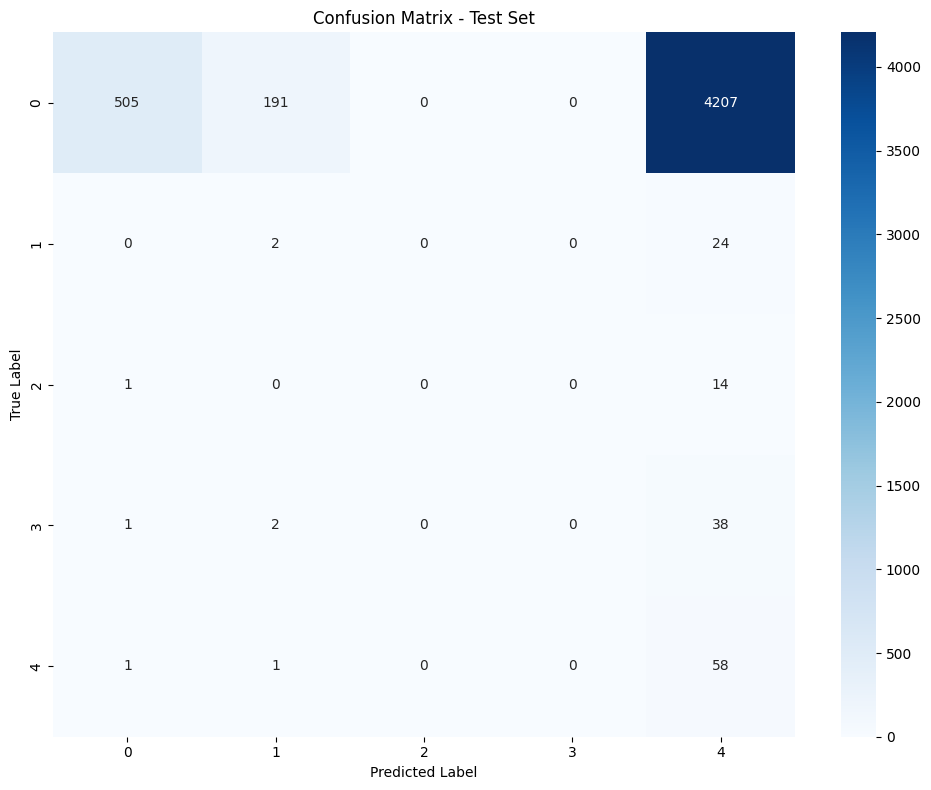

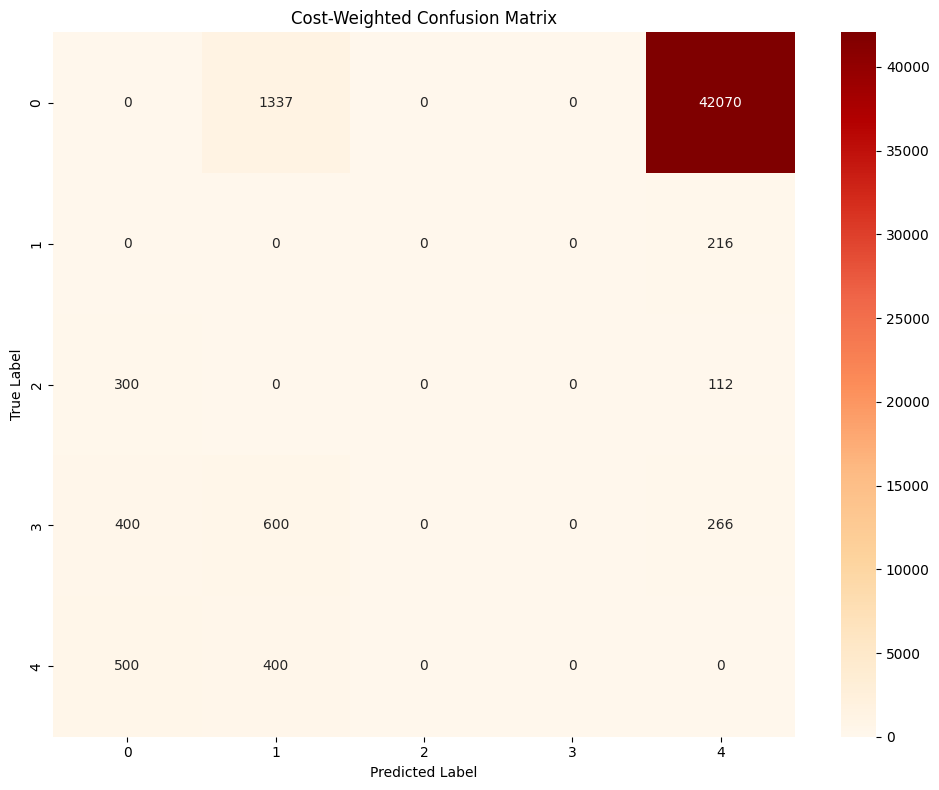

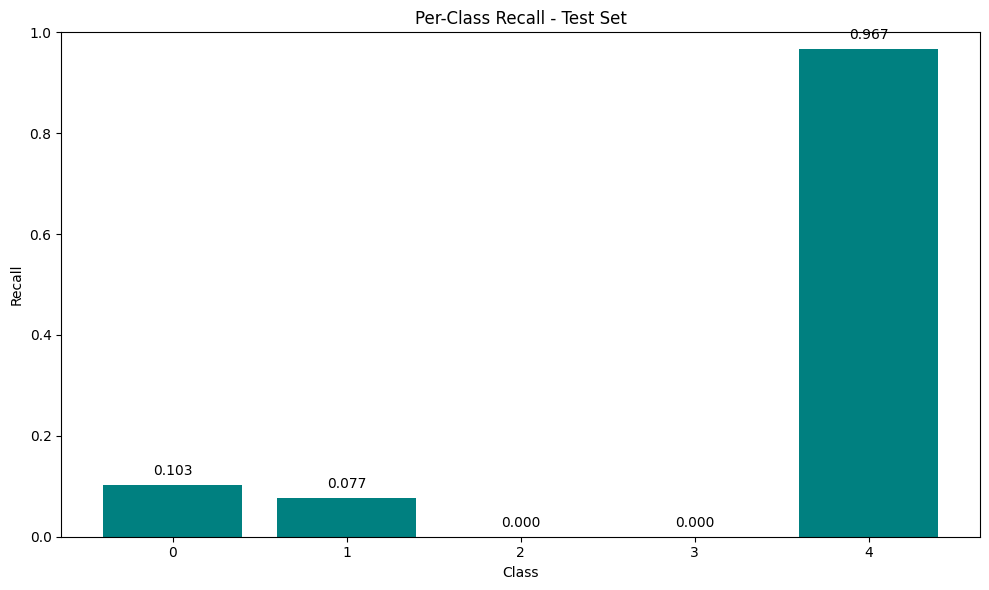

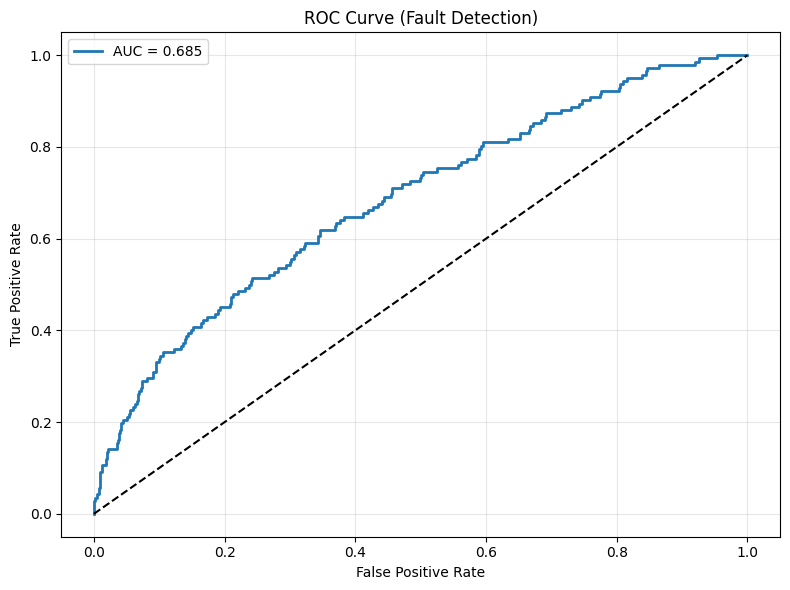

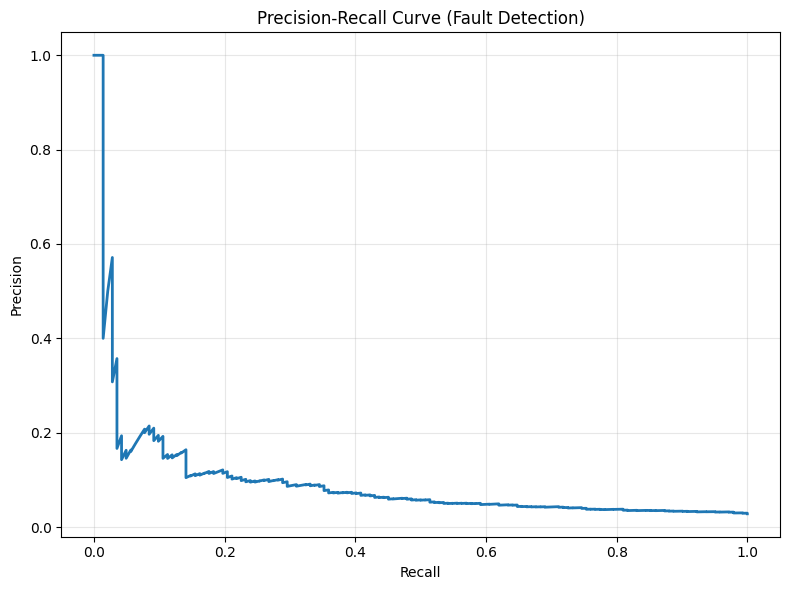

   All plots displayed and saved to 'plots/' directory.

 Unbiased model saved to saved_models/unbiased_winning_model.pkl


In [71]:
# Get predictions for test set
binary_test_probs = binary_model.predict_proba(X_test)[:, 1]
severity_test_probs = severity_model.predict_proba(X_test)
severity_test_c4 = severity_test_probs[:, -1]   # last column = class 4
severity_test_pred = severity_model.predict(X_test)

print("\n" + "="*60)
print(" FINAL EVALUATION ON TEST SET (UNBIASED)")
print("="*60)

binary_test_pred = (binary_test_probs >= best_binary_th).astype(int)
final_test = predict_with_override(binary_test_pred, severity_test_c4, severity_test_pred, best_c4_th)

test_cost = sum(COST_MATRIX[int(test_y[i]), int(final_test[i])] for i in range(len(test_y)))
test_cm = confusion_matrix(test_y, final_test, labels=[0,1,2,3,4])
test_recall4 = recall_score(test_y, final_test, labels=[4], average=None)[0] if (test_y==4).sum()>0 else 0
test_recall_any = recall_score((test_y>0).astype(int), (final_test>0).astype(int))
test_bal_acc = balanced_accuracy_score(test_y, final_test)

# Validation results (for completeness)
binary_val_pred_final = (binary_val_probs >= best_binary_th).astype(int)
final_val = predict_with_override(binary_val_pred_final, severity_val_c4, severity_val_pred, best_c4_th)
val_cm = confusion_matrix(val_y, final_val, labels=[0,1,2,3,4])
val_recall4 = recall_score(val_y, final_val, labels=[4], average=None)[0] if (val_y==4).sum()>0 else 0

print("\n" + "="*80)
print(" VALIDATION SET RESULTS")
print("="*80)
print_confusion_matrix_paper_format(val_cm, "Table 6. Confusion matrix for the validation dataset")
print(f"\nValidation Cost: {best_val_cost_binary:.0f}")
print(f"Class 4 Recall: {val_recall4*100:.1f}%")
print(f"Binary threshold (tuned): {best_binary_th:.3f}")
print(f"Class-4 threshold (tuned): {best_c4_th:.3f}")

print("\n" + "="*80)
print(" TEST SET RESULTS (UNBIASED – NO LEAKAGE)")
print("="*80)
print_confusion_matrix_paper_format(test_cm, "Table 7. Confusion matrix for the test dataset")
print(f"\nTest Cost:        {test_cost:.0f}")
print(f"Class 4 Recall:   {test_recall4*100:.1f}%")
print(f"Any Fault Recall: {test_recall_any*100:.1f}%")
print(f"Balanced Accuracy:{test_bal_acc*100:.1f}%")

# Compare with paper
print("\n" + "="*80)
print(" COMPARISON WITH KIM & KIM (2026) PAPER")
print("="*80)
print("\nTable 8. Total misclassification costs on the validation and test datasets")
print("-" * 60)
print(f"{'Dataset':>12} | {'Paper Cost':>12} | {'Our Cost':>12} | {'Difference':>12}")
print("-" * 60)
print(f"{'Validation':>12} | {PAPER_VALIDATION_COST:>12,} | {best_val_cost_binary:>12,.0f} | {best_val_cost_binary - PAPER_VALIDATION_COST:>+12,.0f}")
print(f"{'Test':>12} | {PAPER_COST:>12,} | {test_cost:>12,.0f} | {test_cost - PAPER_COST:>+12,.0f}")
print("-" * 60)

paper_test_recall4 = 46 / 60
print(f"\nClass 4 Recall Comparison:")
print(f"   Paper: {paper_test_recall4*100:.1f}% (46/60)")
print(f"Our: {test_recall4*100:.1f}% "f"({int(test_cm[4,4])}/{(test_y==4).sum()})")

if test_cost < PAPER_COST:
    improvement = PAPER_COST - test_cost
    print(f"\nOur model achieved a lower test cost by {improvement:.0f} compared with the reported paper result.")
else:
    gap = test_cost - PAPER_COST
    print(f"\nOur model's test cost was {gap:.0f} higher than the reported paper result.")

print("\n Generating publication plots...")
fault_probs = binary_test_probs

plot_confusion_matrix(test_cm, classes=[0,1,2,3,4],
                     title="Confusion Matrix - Test Set",
                     filename="plots/confusion_matrix.png")
plot_cost_weighted_confusion(test_y, final_test, COST_MATRIX,
                            title="Cost-Weighted Confusion Matrix",
                            filename="plots/cost_weighted_confusion.png")
plot_class_recall(test_y, final_test,
                 title="Per-Class Recall - Test Set",
                 filename="plots/class_recall.png")
plot_roc_curve(fault_probs, test_y,
              title="ROC Curve (Fault Detection)",
              filename="plots/roc_curve.png")
plot_pr_curve(fault_probs, test_y,
             title="Precision-Recall Curve (Fault Detection)",
             filename="plots/pr_curve.png")

print("   All plots displayed and saved to 'plots/' directory.")

with open('saved_models/unbiased_winning_model.pkl', 'wb') as f:
    pickle.dump((binary_model, best_binary_th, severity_model, best_c4_th), f)
print("\n Unbiased model saved to saved_models/unbiased_winning_model.pkl")

In [ ]:
import pandas as pd

print("\n" + "="*60)
print(" DIAGNOSTIC: SEVERITY MODEL CLASS-4 PROBABILITY (TEST SET)")
print("="*60)

print(pd.Series(severity_test_c4).describe())
print(f"\nSamples crossing c4_th ({best_c4_th:.3f}): {(severity_test_c4 > best_c4_th).sum()} / {len(severity_test_c4)}")

# Break it down by TRUE class to see where the false triggers come from
print("\nP(class 4) distribution by true class:")
for cls in [0, 1, 2, 3, 4]:
    mask = (test_y == cls)
    if mask.sum() > 0:
        vals = severity_test_c4[mask]
        over_th = (vals > best_c4_th).sum()
        print(f"   True class {cls}: mean={vals.mean():.3f}, "
              f"median={pd.Series(vals).median():.3f}, "
              f"crossing threshold={over_th}/{mask.sum()}")

DELTA THRESHOLD ANALYZER FOR SCANIA DATASET

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Configuration
# Define DRIVE_DATA_ROOT if it's not already defined (e.g., from a previous cell)
if 'DRIVE_DATA_ROOT' not in globals():
    # Fallback/default path. User should ensure the correct path is set in the initial configuration cell.
    DRIVE_DATA_ROOT = "/content/drive/MyDrive/scania"

DATA_ROOT = DRIVE_DATA_ROOT

In [ ]:
# print("="*60)
print(" DELTA THRESHOLD ANALYZER")
# print("="*60)

# Load training data (has failure times)
train_op = pd.read_csv(os.path.join(DATA_ROOT, 'train_operational_readouts.csv'))
train_tte = pd.read_csv(os.path.join(DATA_ROOT, 'train_tte.csv'))

# Load validation labels (for target distribution)
val_labels = pd.read_csv(os.path.join(DATA_ROOT, 'validation_labels.csv'))

In [ ]:
print("\n Analyzing training set failure times...")

# Get vehicles that had failures
failed_vehicles = train_tte[train_tte['in_study_repair'] == 1].copy()
print(f"Vehicles with failures: {len(failed_vehicles)}")

# Get last observation times for these vehicles
last_obs_train = train_op.groupby('vehicle_id')['time_step'].max().reset_index()
last_obs_train.columns = ['vehicle_id', 'last_time_step']

# Merge to get delta for failed vehicles
train_failures = failed_vehicles.merge(last_obs_train, on='vehicle_id', how='left')
train_failures['delta'] = train_failures['length_of_study_time_step'] - train_failures['last_time_step']

print(f"\n Training failure deltas statistics:")
print(f"  Count: {len(train_failures)}")
print(f"  Min delta: {train_failures['delta'].min():.0f}")
print(f"  Max delta: {train_failures['delta'].max():.0f}")
print(f"  Mean delta: {train_failures['delta'].mean():.0f}")
print(f"  Median delta: {train_failures['delta'].median():.0f}")
print(f"  Std delta: {train_failures['delta'].std():.0f}")

# Percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
print(f"\n Delta percentiles:")
for p in percentiles:
    print(f"  {p}th percentile: {train_failures['delta'].quantile(p/100):.0f}")

In [ ]:
print("\n" + "="*60)
print(" VALIDATION SET CLASS DISTRIBUTION (TARGET)")
print("="*60)

if 'class_label' in val_labels.columns:
    val_labels.rename(columns={'class_label': 'class'}, inplace=True)

val_dist = val_labels['class'].value_counts().sort_index()
print(f"\nValidation class distribution:")
for class_label in [0, 1, 2, 3, 4]:
    count = val_dist.get(class_label, 0)
    percentage = (count / len(val_labels)) * 100
    print(f"  Class {class_label}: {count} ({percentage:.1f}%)")

# Failure classes only (1-4)
failure_dist = val_dist[1:5] if len(val_dist) > 4 else val_dist
total_failures = failure_dist.sum()
print(f"\n Failure class distribution (target):")
for class_label in [1, 2, 3, 4]:
    count = val_dist.get(class_label, 0)
    if total_failures > 0:
        pct_of_failures = (count / total_failures) * 100
        print(f"  Class {class_label}: {count} ({pct_of_failures:.1f}% of failures)")

In [ ]:
print("\n" + "="*60)
print("🔧 FINDING OPTIMAL THRESHOLDS")
print("="*60)

# Sort deltas
sorted_deltas = np.sort(train_failures['delta'].values)

# Calculate cumulative percentages for target distribution
if total_failures > 0:
    # Target percentages for each class
    target_pct_class4 = val_dist.get(4, 0) / total_failures
    target_pct_class3 = val_dist.get(3, 0) / total_failures
    target_pct_class2 = val_dist.get(2, 0) / total_failures
    target_pct_class1 = val_dist.get(1, 0) / total_failures

    print(f"\n Target distribution of failures:")
    print(f"  Class 4: {target_pct_class4*100:.1f}% (smallest deltas)")
    print(f"  Class 3: {target_pct_class3*100:.1f}%")
    print(f"  Class 2: {target_pct_class2*100:.1f}%")
    print(f"  Class 1: {target_pct_class1*100:.1f}% (largest deltas)")

    # Calculate thresholds
    cum_pct = 0

    # Class 4 threshold (smallest deltas)
    cum_pct += target_pct_class4
    idx_class4 = int(cum_pct * len(sorted_deltas))
    if idx_class4 >= len(sorted_deltas):
        idx_class4 = len(sorted_deltas) - 1
    threshold_class4 = sorted_deltas[idx_class4]

    # Class 3 threshold
    cum_pct += target_pct_class3
    idx_class3 = int(cum_pct * len(sorted_deltas))
    if idx_class3 >= len(sorted_deltas):
        idx_class3 = len(sorted_deltas) - 1
    threshold_class3 = sorted_deltas[idx_class3]

    # Class 2 threshold
    cum_pct += target_pct_class2
    idx_class2 = int(cum_pct * len(sorted_deltas))
    if idx_class2 >= len(sorted_deltas):
        idx_class2 = len(sorted_deltas) - 1
    threshold_class2 = sorted_deltas[idx_class2]

    print(f"\n OPTIMAL THRESHOLDS FOR YOUR DATA:")
    print(f"  Class 4 (imminent failure): delta < {threshold_class4:.0f}")
    print(f"  Class 3: delta < {threshold_class3:.0f}")
    print(f"  Class 2: delta < {threshold_class2:.0f}")
    print(f"  Class 1: delta >= {threshold_class2:.0f}")

    print(f"\n Update your get_class function with:")
    print(f"""
def get_class(row):
    if row['in_study_repair'] == 0:
        return 0
    delta = row['length_of_study_time_step'] - row['last_time_step']
    if delta < {threshold_class4:.0f}:
        return 4
    elif delta < {threshold_class3:.0f}:
        return 3
    elif delta < {threshold_class2:.0f}:
        return 2
    else:
        return 1
    """)

In [ ]:
print("\n Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of training deltas
axes[0, 0].hist(train_failures['delta'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(train_failures['delta'].median(), color='r', linestyle='--',
                   label=f'Median: {train_failures["delta"].median():.0f}')
if total_failures > 0:
    axes[0, 0].axvline(threshold_class4, color='g', linestyle=':',
                       label=f'Class 4 threshold: {threshold_class4:.0f}')
    axes[0, 0].axvline(threshold_class3, color='orange', linestyle=':',
                       label=f'Class 3 threshold: {threshold_class3:.0f}')
    axes[0, 0].axvline(threshold_class2, color='purple', linestyle=':',
                       label=f'Class 2 threshold: {threshold_class2:.0f}')
axes[0, 0].set_xlabel('Delta (time steps before failure)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of Training Failure Deltas')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Validation class distribution
classes = [0, 1, 2, 3, 4]
counts = [val_dist.get(c, 0) for c in classes]
colors = ['blue', 'orange', 'green', 'red', 'purple']
bars = axes[0, 1].bar(classes, counts, color=colors, alpha=0.7)
axes[0, 1].set_xlabel('Class')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Validation Set Class Distribution')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 5,
                   f'{count}', ha='center', va='bottom')

# 3. Cumulative distribution with thresholds
axes[1, 0].ecdf(train_failures['delta'])
axes[1, 0].set_xlabel('Delta')
axes[1, 0].set_ylabel('Cumulative Probability')
axes[1, 0].set_title('Cumulative Distribution of Training Deltas')
if total_failures > 0:
    axes[1, 0].axvline(threshold_class4, color='g', linestyle='--', alpha=0.7,
                       label=f'Class 4 threshold: {threshold_class4:.0f}')
    axes[1, 0].axvline(threshold_class3, color='orange', linestyle='--', alpha=0.7,
                       label=f'Class 3 threshold: {threshold_class3:.0f}')
    axes[1, 0].axvline(threshold_class2, color='purple', linestyle='--', alpha=0.7,
                       label=f'Class 2 threshold: {threshold_class2:.0f}')

    # Add target percentages
    y_pos = target_pct_class4 / 2
    axes[1, 0].text(threshold_class4 * 0.5, y_pos, f'Class 4\n{target_pct_class4*100:.1f}%',
                   ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8))

    y_pos = target_pct_class4 + target_pct_class3/2
    axes[1, 0].text((threshold_class4 + threshold_class3)/2, y_pos,
                   f'Class 3\n{target_pct_class3*100:.1f}%',
                   ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8))

    y_pos = target_pct_class4 + target_pct_class3 + target_pct_class2/2
    axes[1, 0].text((threshold_class3 + threshold_class2)/2, y_pos,
                   f'Class 2\n{target_pct_class2*100:.1f}%',
                   ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8))
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Threshold sensitivity
thresholds = np.linspace(train_failures['delta'].min(), train_failures['delta'].max(), 100)
class4_counts = [(t > train_failures['delta']).sum() for t in thresholds]
axes[1, 1].plot(thresholds, class4_counts, 'b-', linewidth=2)
axes[1, 1].set_xlabel('Threshold (delta < threshold)')
axes[1, 1].set_ylabel('Number of Class 4 Samples')
axes[1, 1].set_title('Class 4 Count vs. Threshold')
if total_failures > 0:
    axes[1, 1].axvline(threshold_class4, color='r', linestyle='--',
                       label=f'Optimal: {threshold_class4:.0f}')
    axes[1, 1].axhline(val_dist.get(4, 0), color='g', linestyle=':',
                       label=f'Target: {val_dist.get(4, 0)}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('delta_threshold_analysis.png', dpi=300)
plt.show()

print("\n" + "="*60)
print(" Analysis complete!")
print("="*60)
print("\n Files generated:")
print("  - delta_threshold_analysis.png (visualizations)")
print("\n Next steps:")
print("  1. Update your get_class function with the suggested thresholds")
print("  2. Run your main experiment again")